In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# 读取数据
df = pd.read_csv('data/titanic_train.csv')

# 查看前5行
print(df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
# 1. 查看数据基本信息：多少行多少列、每列类型、每列有没有空值
df.info()

# 2. 数值列的统计描述：均值、最大最小、四分位数等
df.describe()

# 3. 检查缺失值：每列缺了多少个
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
# 1. 用中位数填充 Age（中位数比均值更抗极端值，比如百岁老人不会拉偏）
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. 用众数（出现最多的值）填充 Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin 缺失太多，直接删除这一列
df = df.drop(columns=['Cabin'])

# 4. 验证：再查一次缺失值，应该只剩 0
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [4]:
# 把性别翻译成数字：male→0, female→1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 把登船港口翻译成数字：S→0, C→1, Q→2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 验证编码结果：Sex 应该变成 0/1，Embarked 变成 0/1/2
print(df[['Sex', 'Embarked']].head(10))
print()
print("Sex 取值：", df['Sex'].unique())
print("Embarked 取值：", df['Embarked'].unique())


   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0
5    0         2
6    0         0
7    0         0
8    1         0
9    1         1

Sex 取值： [0 1]
Embarked 取值： [0 1 2]


In [5]:
from sklearn.model_selection import train_test_split

# 特征X：去掉目标列Survived，再去掉没用的ID/姓名/船票号
X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])
# 目标y：要预测的"是否生还"
y = df['Survived']

# 划分：80%训练，20%验证；random_state=42保证每次结果一样
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("训练集大小：", X_train.shape)
print("验证集大小：", X_val.shape)


训练集大小： (712, 7)
验证集大小： (179, 7)


In [6]:
from sklearn.linear_model import LogisticRegression

# 创建模型（max_iter=1000：允许迭代更多次，保证收敛）
model = LogisticRegression(max_iter=1000)

# 用训练集"做练习题"
model.fit(X_train, y_train)

# 在验证集上"考试"——预测结果
y_pred = model.predict(X_val)

# 看一眼前10个预测结果（1=生还，0=遇难）
print("预测结果：", y_pred[:10])
print("真实答案：", y_val.values[:10])


预测结果： [0 0 0 1 1 1 1 0 1 1]
真实答案： [1 0 0 1 1 1 1 0 1 1]


In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("Accuracy（准确率）: {:.4f}".format(accuracy_score(y_val, y_pred)))
print("Precision（精确率）: {:.4f}".format(precision_score(y_val, y_pred)))
print("Recall（召回率）:   {:.4f}".format(recall_score(y_val, y_pred)))
print("F1-score:           {:.4f}".format(f1_score(y_val, y_pred)))
print("\n混淆矩阵 Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n完整分类报告:")
print(classification_report(y_val, y_pred))


Accuracy（准确率）: 0.7989
Precision（精确率）: 0.7714
Recall（召回率）:   0.7297
F1-score:           0.7500

混淆矩阵 Confusion Matrix:
[[89 16]
 [20 54]]

完整分类报告:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



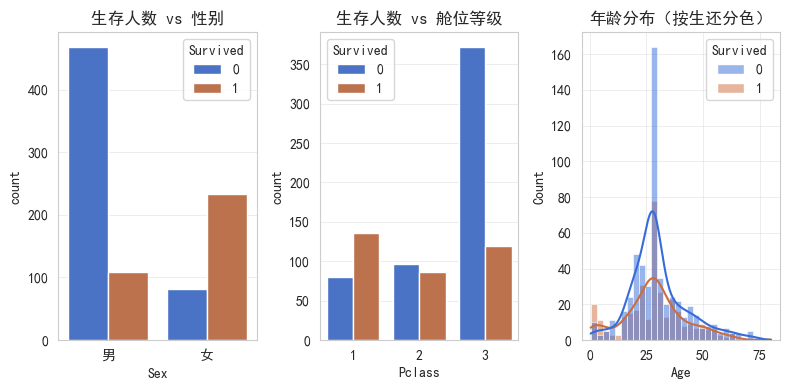

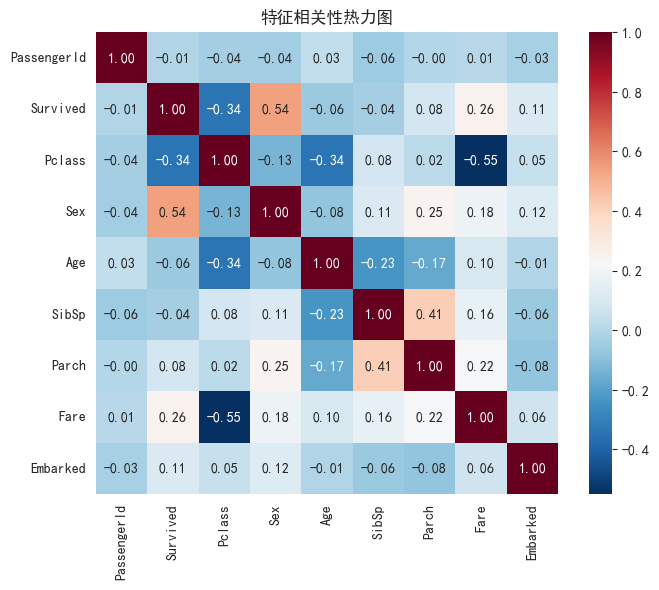

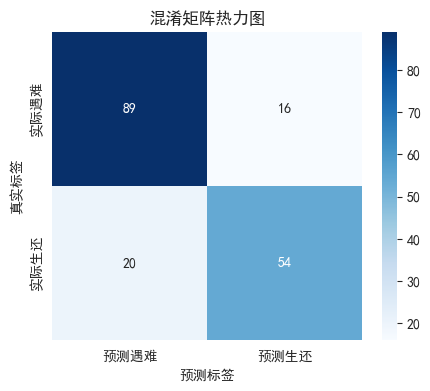

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置整体画图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

# 设置中文字体（Windows自带微软雅黑）和负号正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 图1：性别 vs 生存率（0=遇难 1=生还）
plt.subplot(1, 3, 1)
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('生存人数 vs 性别')
plt.xticks([0, 1], ['男', '女'])

# 图2：舱位等级 vs 生存率
plt.subplot(1, 3, 2)
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('生存人数 vs 舱位等级')

# 图3：年龄分布（按是否生还分色）
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30)
plt.title('年龄分布（按生还分色）')

plt.tight_layout()
plt.show()

# 图4：相关性热力图——看所有特征之间、特征与生存的相关程度
plt.figure(figsize=(8, 6))
# 只挑选数值列计算相关性
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='RdBu_r', fmt='.2f', square=True)
plt.title('特征相关性热力图')
plt.show()

# 图5：混淆矩阵热力图——把前面评估的混淆矩阵画出来（更直观）
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['预测遇难', '预测生还'],
            yticklabels=['实际遇难', '实际生还'])
plt.title('混淆矩阵热力图')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()
